### PSA with 2nd phase only a single agent
### DBSA with 8 parallel agents

In [1]:
# 📦 Schritt 1: Bibliotheken importieren
import pandas as pd
import glob
import os

# 📁 Schritt 2: Pfad zu den Metrics-Dateien definieren
folder_path = "/Users/niklas/Desktop/Diplomarbeit/OptRail_Railroad_Construction/Data/Solutions_TPSA_1_P_Test/"
file_pattern = os.path.join(folder_path, "Metrics_*.csv")

# 📂 Schritt 3: Alle passenden CSV-Dateien finden
file_list = glob.glob(file_pattern)
print(f"{len(file_list)} Dateien gefunden.")

# 📊 Schritt 4: Alle Dateien einlesen und zusammenfügen
all_dfs = [pd.read_csv(file) for file in file_list]
full_df = pd.concat(all_dfs, ignore_index=True)
print("Daten erfolgreich zusammengeführt.")
display(full_df.head())

# 📈 Schritt 5: Durchschnittswerte pro Instanz + Algorithmus berechnen
average_df = full_df.groupby(["Instance", "Algorithm"], as_index=False).mean()
print("Durchschnittswerte berechnet.")
display(average_df.head())

# 💾 Schritt 6: Ergebnis abspeichern
output_path = os.path.join(folder_path, "Metrics_averaged.csv")
average_df.to_csv(output_path, index=False)
print(f"Aggregierte Datei gespeichert unter: {output_path}")

5 Dateien gefunden.
Daten erfolgreich zusammengeführt.


,Instance,Algorithm,Improvement_Time,DCI,Distribution Metric (DM),Hypevolume (Monte Carlo),PCI,PF-Share,Spacing,Spread
0,a3_o80_m10_an10_ar9_reduced,PSA,285.93,0.244444,0.795241,0.161807,0.357048,5.633803,0.155115,0.495959
1,a3_o80_m10_an10_ar9_reduced,DBSA,52.25,0.866667,0.255813,0.390000,0.106212,71.830986,0.059655,0.529747
2,a3_o80_m10_an10_ar9_reduced,TPSA,99.92,0.672222,0.257458,0.302985,0.138281,22.535211,0.106893,0.708571
3,a5_o96_m10_an10_ar10_reduced,PSA,214.44,0.446667,0.273077,0.207780,0.264326,12.048193,0.083764,0.583769
4,a5_o96_m10_an10_ar10_reduced,DBSA,45.64,0.837778,0.170788,0.372942,0.138987,73.493976,0.046256,0.521944


Durchschnittswerte berechnet.


,Instance,Algorithm,Improvement_Time,DCI,Distribution Metric (DM),Hypevolume (Monte Carlo),PCI,PF-Share,Spacing,Spread
0,a10_o107_m5_an57_ar12,DBSA,44.184,0.737352,0.189914,0.273425,0.233140,57.858608,0.041505,0.504685
1,a10_o107_m5_an57_ar12,PSA,181.326,0.408427,1.038887,0.293904,0.151162,18.728700,0.054545,0.419282
2,a10_o107_m5_an57_ar12,TPSA,61.572,0.574221,0.211488,0.186661,0.298176,23.412692,0.041687,0.687197
3,a10_o114_m6_an57_ar11,DBSA,55.782,0.796156,0.154013,0.272588,0.159351,58.530333,0.071008,0.832956
4,a10_o114_m6_an57_ar11,PSA,338.694,0.425926,0.886508,0.359150,0.113982,21.992646,0.121740,0.763518


Aggregierte Datei gespeichert unter: /Users/niklas/Desktop/Diplomarbeit/OptRail_Railroad_Construction/Data/Solutions_TPSA_1_P_Test/Metrics_averaged.csv


In [2]:
import pandas as pd

# Datei einlesen (Pfad ggf. anpassen, falls Datei woanders liegt)
df = pd.read_csv("Metrics_averaged.csv")

# Rundung zur besseren Lesbarkeit (optional)
df_rounded = df.round(3)

# Ausgabe als DataFrame mit schöner Formatierung
from IPython.display import display, HTML
display(HTML(df_rounded.to_html(index=False)))

Instance,Algorithm,Improvement_Time,DCI,Distribution Metric (DM),Hypevolume (Monte Carlo),PCI,PF-Share,Spacing,Spread
a10_o107_m5_an57_ar12,DBSA,44.184,0.737,0.190,0.273,0.233,57.859,0.042,0.505
a10_o107_m5_an57_ar12,PSA,181.326,0.408,1.039,0.294,0.151,18.729,0.055,0.419
a10_o107_m5_an57_ar12,TPSA,61.572,0.574,0.211,0.187,0.298,23.413,0.042,0.687
a10_o114_m6_an57_ar11,DBSA,55.782,0.796,0.154,0.273,0.159,58.530,0.071,0.833
a10_o114_m6_an57_ar11,PSA,338.694,0.426,0.887,0.359,0.114,21.993,0.122,0.764
a10_o114_m6_an57_ar11,TPSA,81.866,0.472,0.211,0.196,0.272,19.477,0.080,0.950
a10_o128_m6_an51_ar13,DBSA,51.866,0.750,0.240,0.004,0.261,57.157,0.046,0.821
a10_o128_m6_an51_ar13,PSA,206.588,0.368,0.805,0.004,0.185,19.943,0.111,0.811
a10_o128_m6_an51_ar13,TPSA,75.674,0.540,0.266,0.003,0.286,22.900,0.070,0.978
a10_o144_m6_an53_ar12,DBSA,37.664,0.701,0.168,0.448,0.246,50.892,0.057,0.528


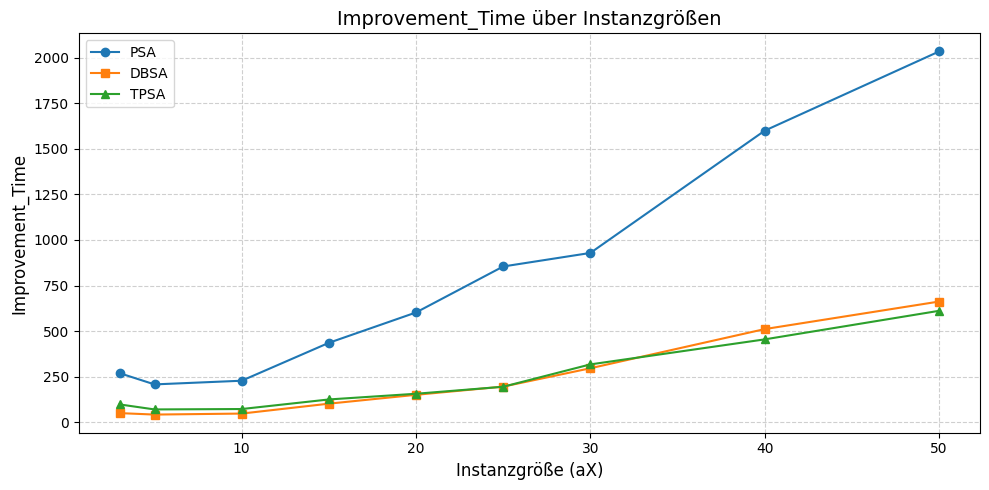

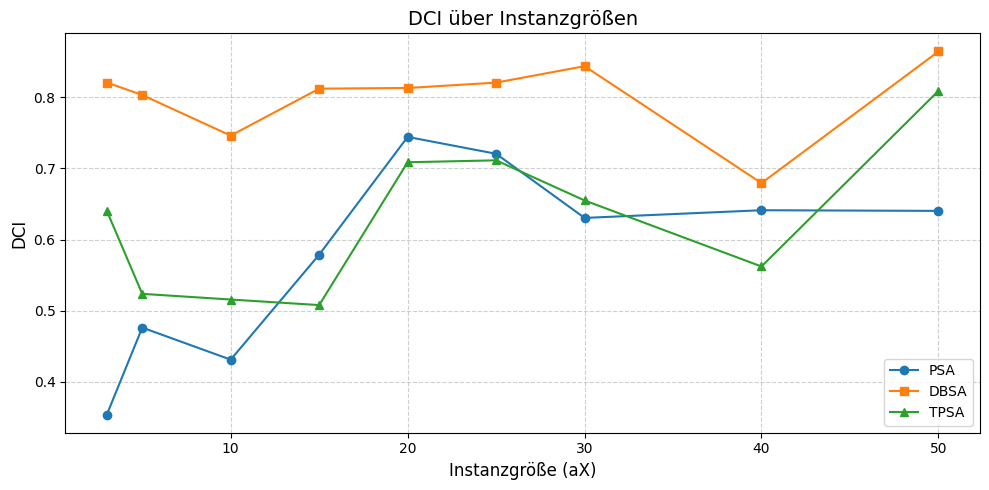

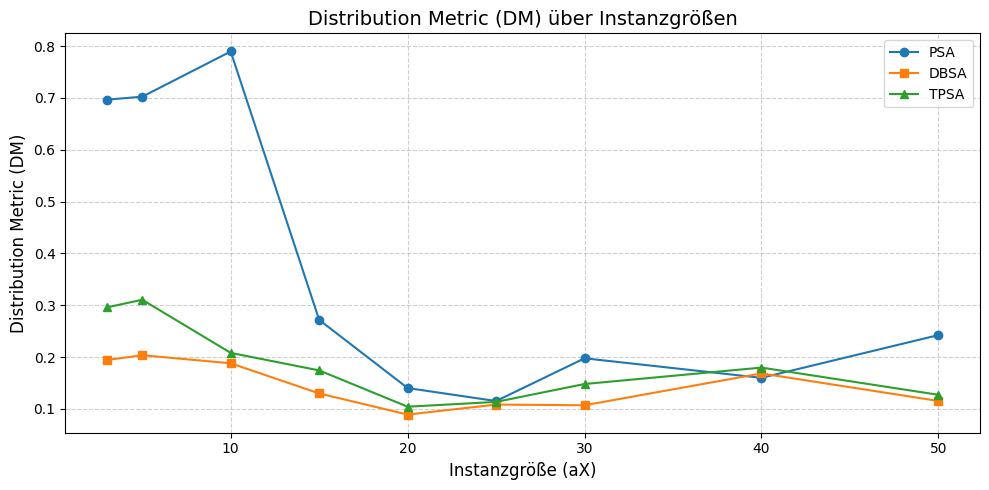

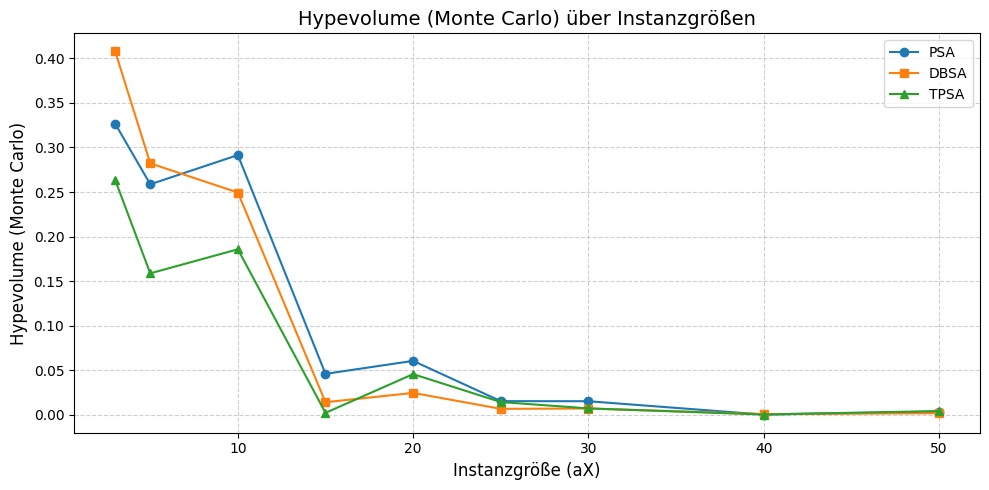

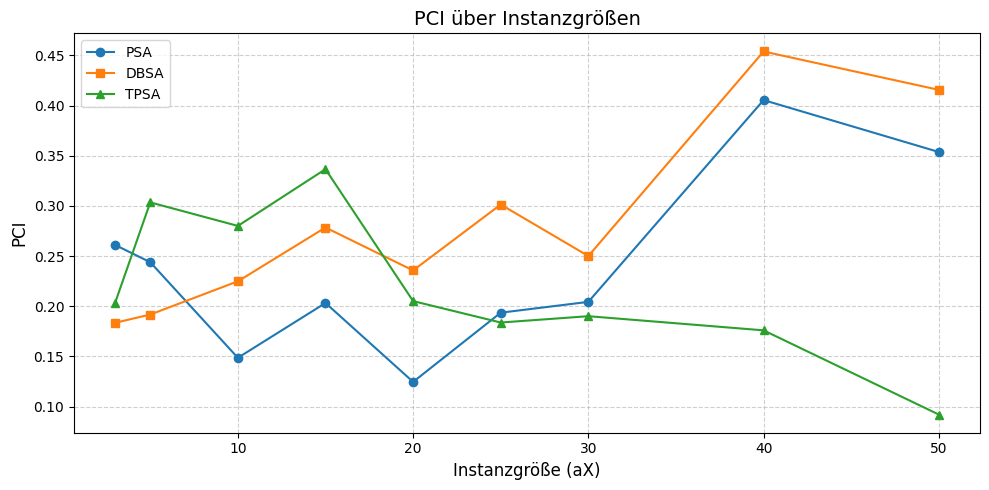

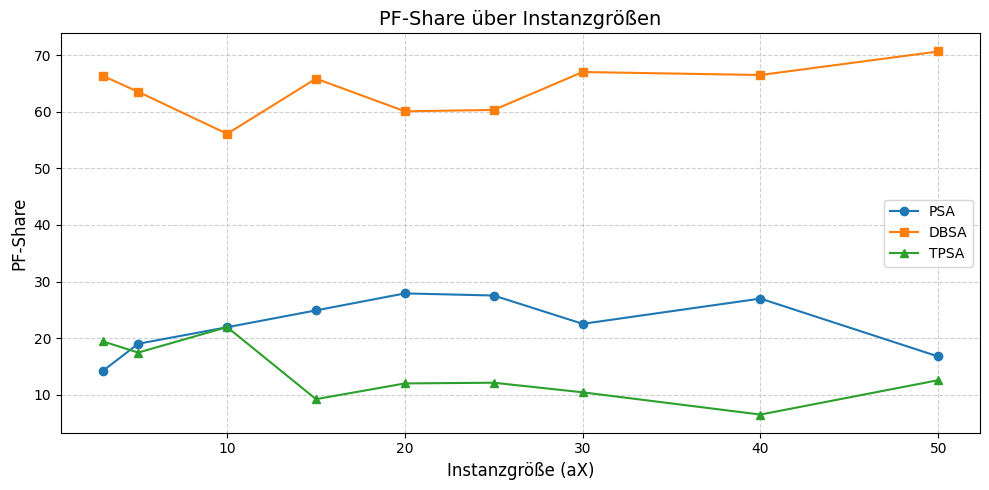

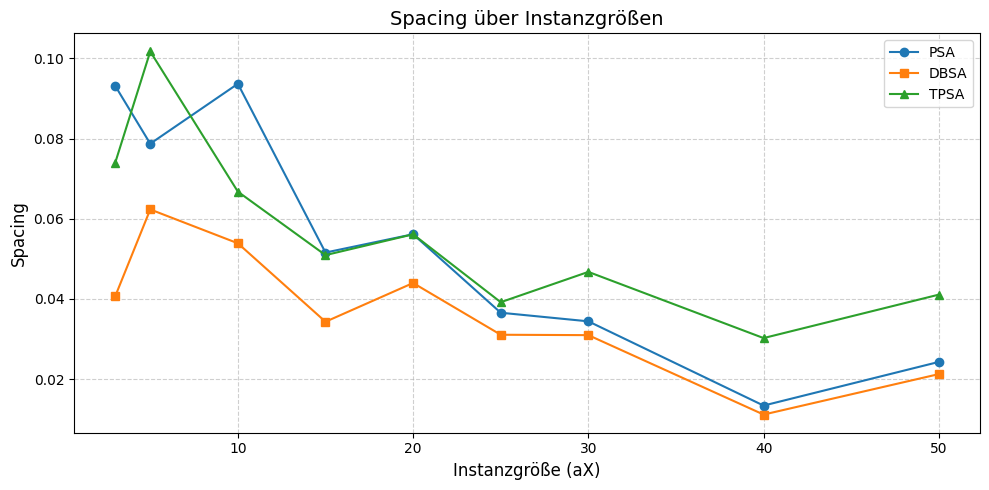

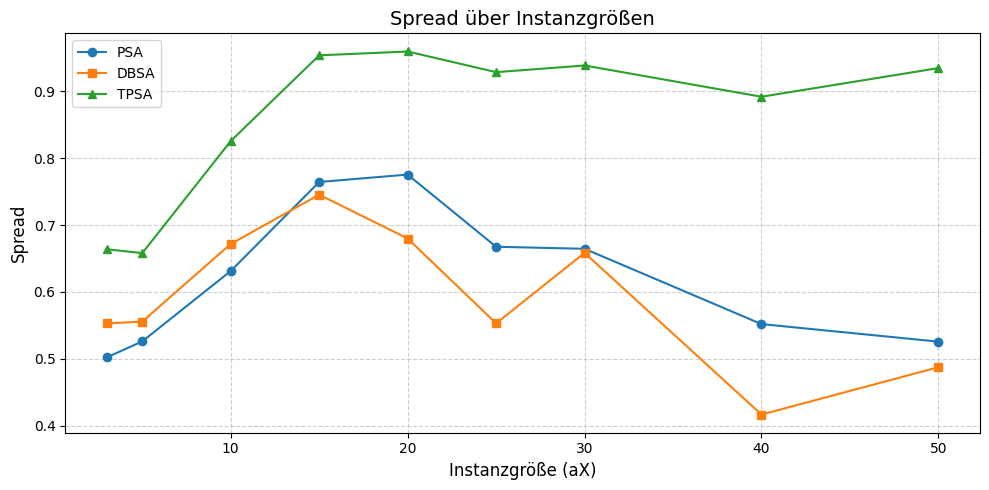

In [3]:
# 📦 Imports
import pandas as pd
import matplotlib.pyplot as plt

# 📂 Datei einlesen
file_path = "/Users/niklas/Desktop/Diplomarbeit/OptRail_Railroad_Construction/Data/Solutions_TPSA_1_P_Test/Metrics_averaged.csv"
df = pd.read_csv(file_path)

# 🔍 Instanzgröße extrahieren (z. B. 'a3_o80' → 3)
df["Instance_Size"] = df["Instance"].str.extract(r"a(\d+)_").astype(int)

# 🧹 Metriken auswählen (alle außer 'Instance', 'Algorithm', 'Instance_Size')
metrics = [col for col in df.columns if col not in ["Instance", "Algorithm", "Instance_Size"]]

# 🧮 Mittelwert pro (Instance_Size, Algorithm)
agg_df = df.groupby(["Instance_Size", "Algorithm"], as_index=False)[metrics].mean()

# 📊 Sortieren nach Instanzgröße
agg_df = agg_df.sort_values("Instance_Size")

# 🎨 Visualisierung: Jede Metrik als eigenes Diagramm
for metric in metrics:
    plt.figure(figsize=(10, 5))

    # PSA-Linie
    psa_data = agg_df[agg_df["Algorithm"] == "PSA"]
    plt.plot(psa_data["Instance_Size"], psa_data[metric], marker="o", label="PSA")

    # DBSA-Linie
    dbsa_data = agg_df[agg_df["Algorithm"] == "DBSA"]
    plt.plot(dbsa_data["Instance_Size"], dbsa_data[metric], marker="s", label="DBSA")

    # TPSA-Linie
    tpsa_data = agg_df[agg_df["Algorithm"] == "TPSA"]
    plt.plot(tpsa_data["Instance_Size"], tpsa_data[metric], marker="^", label="TPSA")

    # ✨ Formatierung
    plt.title(f"{metric} über Instanzgrößen", fontsize=14)
    plt.xlabel("Instanzgröße (aX)", fontsize=12)
    plt.ylabel(metric, fontsize=12)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [4]:
# Durchschnittswerte je Algorithmus
df.groupby("Algorithm").mean(numeric_only=True).round(3)

,Improvement_Time,DCI,Distribution Metric (DM),Hypevolume (Monte Carlo),PCI,PF-Share,Spacing,Spread,Instance_Size
Algorithm,,,,,,,,,
DBSA,183.161,0.787,0.156,0.145,0.268,62.065,0.041,0.611,19.0
PSA,653.551,0.542,0.474,0.158,0.215,22.301,0.064,0.625,19.0
TPSA,192.973,0.598,0.191,0.103,0.234,15.634,0.059,0.853,19.0


In [5]:
# Standardabweichungen je Algorithmus
df.groupby("Algorithm").std(numeric_only=True).round(3)

,Improvement_Time,DCI,Distribution Metric (DM),Hypevolume (Monte Carlo),PCI,PF-Share,Spacing,Spread,Instance_Size
Algorithm,,,,,,,,,
DBSA,206.515,0.057,0.046,0.177,0.088,5.552,0.017,0.135,14.623
PSA,607.360,0.136,0.332,0.180,0.089,4.633,0.035,0.132,14.623
TPSA,177.733,0.106,0.070,0.124,0.070,5.823,0.021,0.134,14.623
